# Assignment # 1
## Course Title: Advance Deep learning
## Instructor: Dr Zafar

## Roll no: 25015919-002
##  Class : MSCS SEM 2
## University of Gujrat,Main campus

# Question # 1: Implementation of single perceptrons

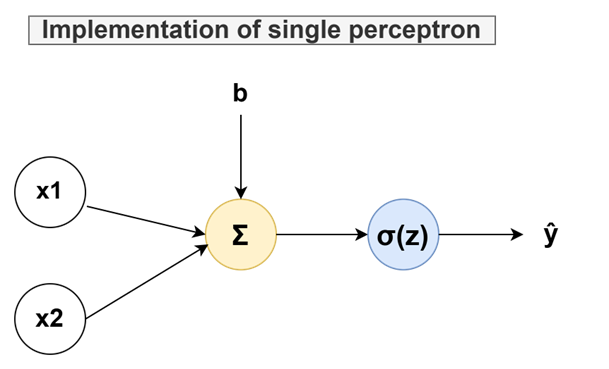
           

## Method 1: Using Manual coding

In [1]:
import math
import numpy as np

In [2]:
def activation(z):  # sigmoid activation function
    return 1 / (1 + math.exp(-z))



In [3]:
def perceptron(X, W, b):

    # Check vector compatibility
    if W.shape[0] != X.shape[0]:
        print("Error: Input and Weight vectors must have same ")
        return None
    else:
        z = 0
        print("Step-by-step calculation:\n")
        for i in range(len(X)):
            product = W[i] * X[i]
            z += product
            print(f"Step {i+1}:")
            print(f"W[{i}] * X[{i}] = {W[i]} * {X[i]} = {product}")
            print(f"Updated z = {z}\n")
        print(f"Adding bias: z = {z} + ({b})")
        z += b
        print(f"Final z after bias = {z}\n")

        # Activation
        y = activation(z)
        print(f"Output after activation = {y}")

        return y


In [4]:
# Input vector
X = np.array([[1],
              [0]])

In [5]:
# Weight vector
W = np.array([0.5,-0.6])

In [6]:
# Bias
b = -0.2

In [7]:
y = perceptron(X, W, b)

Step-by-step calculation:

Step 1:
W[0] * X[0] = 0.5 * [1] = [0.5]
Updated z = [0.5]

Step 2:
W[1] * X[1] = -0.6 * [0] = [-0.]
Updated z = [0.5]

Adding bias: z = [0.5] + (-0.2)
Final z after bias = [0.3]

Output after activation = 0.574442516811659


/tmp/ipython-input-1730569783.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (1 + math.exp(-z))


In [8]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [9]:
print("Final output Manually y =", predict(y))

Final output Manually y = 1


## Method 2: Using built in function

In [11]:
# import libraries
import numpy as np

In [12]:
# Input vector
X = np.array([[1],
              [0],[1]])   # x1,x2,x3

In [13]:
X

array([[1],
       [0],
       [1]])

In [14]:
# Weight vector
W = np.array([0.5, -0.6, 0.8]) # w1, w2, w3


In [15]:
W

array([ 0.5, -0.6,  0.8])

In [16]:
# Bias
b = -0.2

In [17]:
# Sigmoid activation function
def activation(z):
    return 1 / (1 + math.exp(-z))

In [21]:
dproduct = np.dot(W,X)

In [22]:
dproduct

array([1.3])

Calculations of dot product:
(0.5 × 1) + (-0.6 × 0) + (0.8 × 1)


In [24]:
z = dproduct + b # z = 0.5 + 0 + 0.8 - 0.2

In [25]:
z

array([1.1])

In [26]:
# Call the activation function to add non linearity
y = activation(z)

/tmp/ipython-input-564324399.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (1 + math.exp(-z))


In [27]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [28]:
# Output
print("Output using built in functions  y =",predict(y))

Output using built in functions  y = 1


# Question # 2: Implementation of multi lyer perceptrons

## 2.1: Two hiden layers each one have only one perceptron

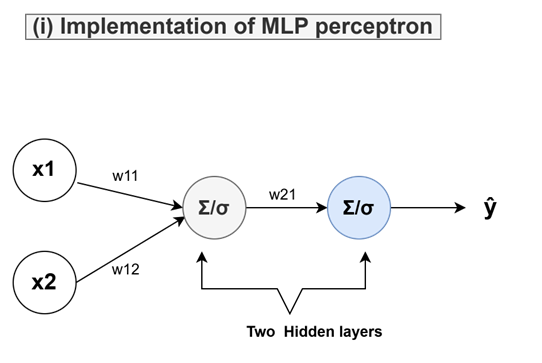

#### Method 1:

In [29]:
import numpy as np

In [30]:
# Sigmoid activation (for output)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [31]:
# ReLU activation (for hidden layers)
def relu(z):
    return max(0, z)

In [32]:
# Fully manual MLP
def MLP_manual_stepby_step(X):
    """
    X: Input column vector of shape (2,1)
    """

    n_input = 2  # number of input features

    # General input check
    if not isinstance(X, np.ndarray):
        print("Error: Input must be a numpy array")
        return None
    if X.shape != (n_input,1):
        print(f"Error: Input vector X must have shape ({n_input},1). Current shape: {X.shape}")
        return None
    else:
        # ---- Hidden Layer 1 ----
        # input vector for hidden layer 1 is X
        W1 = np.array([[0.5, -0.4]])  # 1 neuron, 2 inputs
        b1 = 0.2

        Z1 = 0
        for i in range(n_input):
            product = W1[0,i] * X[i,0]
            Z1 += product
            print(f"Hidden Layer 1 - Step {i+1}: Weight * Input = {product}, cumulative Z1 = {Z1}")
        Z1 += b1
        print("Hidden Layer 1 - After adding bias:", Z1)

        H1 = relu(Z1)
        print("Hidden Layer 1 Output after Relu (H1):", H1)

        # ---- Hidden Layer 2 ----
        # inputs for hidden layer 2  is H1 vector
        # weight vector for hidden layer 2
        W2 = np.array([0.7])  # 1 neuron, input from H1
        b2 = -0.3

        Z2 = 0
        # Only one input H1
        product = W2[0] * H1
        Z2 += product
        print(f"Hidden Layer 2: Weight * H1 = {product}, cumulative Z2 = {Z2}")
        Z2 += b2
        print("Hidden Layer 2 - After adding bias:", Z2)

        H2 = relu(Z2)
        print("Hidden Layer 2 Output after Relu (H2):", H2)

        # ---- Output Layer ----
        W3 = np.array([1.2])  # 1 neuron, input from H2
        b3 = 0.1

        Z3 = 0
        product = W3[0] * H2
        Z3 += product
        print(f"Output Layer: Weight * H2 = {product}, cumulative Z3 = {Z3}")
        Z3 += b3
        print("Output Layer - After adding bias:", Z3)

        Y = sigmoid(Z3)
        print("Final Output after Sigmoid (Y):", Y)

        return Y

In [33]:
X = np.array([[1], [0]])


In [34]:
y = MLP_manual_stepby_step(X)

Hidden Layer 1 - Step 1: Weight * Input = 0.5, cumulative Z1 = 0.5
Hidden Layer 1 - Step 2: Weight * Input = -0.0, cumulative Z1 = 0.5
Hidden Layer 1 - After adding bias: 0.7
Hidden Layer 1 Output after Relu (H1): 0.7
Hidden Layer 2: Weight * H1 = 0.48999999999999994, cumulative Z2 = 0.48999999999999994
Hidden Layer 2 - After adding bias: 0.18999999999999995
Hidden Layer 2 Output after Relu (H2): 0.18999999999999995
Output Layer: Weight * H2 = 0.22799999999999992, cumulative Z3 = 0.22799999999999992
Output Layer - After adding bias: 0.32799999999999996
Final Output after Sigmoid (Y): 0.5812726666092255


In [35]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [36]:
print("Finally,threshhold check for classification problem y = ",predict(y))

Finally,threshhold check for classification problem y =  1


#### Method 2

In [37]:
import numpy as np

In [38]:
# Sigmoid activation
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [39]:
# ReLU activation (for hidden layers)
def relu(z):
    return max(0, z)

In [40]:
# Multi-Layer Perceptron manual with robust input check and step-by-step z
def MLP_manual(X):
    """
    X: Input vector, shape must match input layer (n_inputs,1)
    Returns: Output of MLP
    """

    # ---- Layer configuration ----
    # For example, 2-input features → Hidden1(1) → Hidden2(1) → Output(1)
    n_input = 2  # number of input features

    # General input check
    if not isinstance(X, np.ndarray):
        print("Error: Input must be a numpy array")
        return None
    if X.shape != (n_input,1):
        print(f"Error: Input vector X must have shape ({n_input},1). Current shape: {X.shape}")
        return None

    else:
        # ---- Hidden Layer 1 ----
        # input vector for hidden layer 1 is X
        # Weight vector for hidden layer 1
        W1 = np.array([[0.5, -0.4]])  # 1 neuron, 2 inputs
        b1 = np.array([[0.2]])
        Z1 = np.dot(W1, X) + b1
        print("Hidden Layer 1 weighted sum (Z1):", Z1)
        H1 = relu(Z1)
        print("Hidden Layer 1 output after Relu (H1):", H1)

        # ---- Hidden Layer 2 ----
        # input vector for hidden layer 2 is H1
        # Weight vector for hidden layer 1
        W2 = np.array([[0.7]])  # 1 neuron, input from H1
        b2 = np.array([[-0.3]])
        Z2 = np.dot(W2, H1) + b2
        print("Hidden Layer 2 weighted sum (Z2):", Z2)
        H2 = relu(Z2)
        print("Hidden Layer 2 output after Relu (H2):", H2)

        # ---- Output Layer ----
        W3 = np.array([[1.2]])  # 1 neuron, input from H2
        b3 = np.array([[0.1]])
        Z3 = np.dot(W3, H2) + b3
        print("Output Layer weighted sum (Z3):", Z3)
        Y = sigmoid(Z3)
        print("Final Output after Sigmoid (Y):", Y)

        return Y

In [41]:
# Correct input
X = np.array([[1], [0]])

In [42]:
X

array([[1],
       [0]])

In [43]:
y = MLP_manual(X)


Hidden Layer 1 weighted sum (Z1): [[0.7]]
Hidden Layer 1 output after Relu (H1): [[0.7]]
Hidden Layer 2 weighted sum (Z2): [[0.19]]
Hidden Layer 2 output after Relu (H2): [[0.19]]
Output Layer weighted sum (Z3): [[0.328]]
Final Output after Sigmoid (Y): [[0.58127267]]


In [44]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [45]:
print("Finally,threshhold check for classification problem y = ",predict(y))

Finally,threshhold check for classification problem y =  1


In [46]:
X_wrong = np.array([[1, 0]])  # wrong shape
output_wrong = MLP_manual(X_wrong)

Error: Input vector X must have shape (2,1). Current shape: (1, 2)


## 2.2: Two hiden layers 1st one have two perceptrons and 2nd hidden layer have only one perceptron


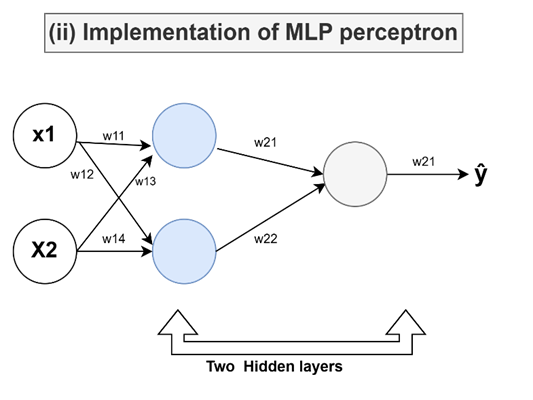

#### Method 1 Manual implementation

In [47]:
 # ---------- Activation Functions ----------
def relu(z):  # for hidden layers
    return max(0, z)

def sigmoid(z):  # for output layer
    return 1 / (1 + np.exp(-z))

In [48]:
# ---------- Manual Weighted Sum ----------
def weighted_sum(W, X, b):
    """
    Compute Z = W*X + b manually
    W: weight row vector (1 x n)
    X: input column vector (n x 1)
    b: bias scalar
    """
    Z = 0
    n = X.shape[0]
    for i in range(n):
        Z += W[i] * X[i,0]
        print(f"W[{i}] * X[{i}] = {W[i]*X[i,0]}")
    Z += b
    print(f"Adding bias {b} → Z = {Z}")
    return Z


In [49]:
# ---------- Multi Layer Perceptron ----------
def MLP_manual_vector(X):

    # -------- General Check --------
    if not isinstance(X, np.ndarray):
        print("Input must be numpy array")
        return None

    if X.shape != (2,1):
        print("Input shape must be (2,1)")
        return None

    print("\nINPUT VECTOR:\n", X)

    # =====================================
    # Hidden Layer 1 (2 Perceptrons)
    # =====================================
    print("\n--- Hidden Layer 1 ---")
    # input vector for hidden layer 1 is X
    W1 = np.array([[0.5, -0.4],   # Neuron 1
                   [0.3, 0.8]])   # Neuron 2
    B1 = np.array([0.2, -0.1])    # Biases

    H1 = np.zeros((2,1))
    for i in range(2):
        z = weighted_sum(W1[i], X, B1[i])
        h = relu(z)
        H1[i,0] = h
        print(f"Neuron {i+1}: z = {z}, h = {h}")

    print("Hidden Layer 1 Output H1:\n", H1)

    # =====================================
    # Hidden Layer 2 (1 Perceptron)
    # =====================================
    print("\n--- Hidden Layer 2 ---")
    # Input vector for hidden layer 2 is H1 from 1st hidden layer
    W2 = np.array([[0.7, 0.6]])   # 1 neuron, weights for H1
    B2 = np.array([-0.3])         # Bias
    Z2 = weighted_sum(W2[0], H1, B2[0])
    H2 = relu(Z2)
    print(f"Hidden Layer 2: z = {Z2}, h = {H2}")

    # =====================================
    # Output Layer
    # =====================================
    print("\n--- Output Layer ---")

    W3 = np.array([1.2])   # 1 neuron, weight for H2
    B3 = 0.1               # Bias
    Z3 = weighted_sum(W3, np.array([[H2]]), B3)
    Y = sigmoid(Z3)
    print(f"Output Layer: z = {Z3}, y = {Y}")

    return Y

In [50]:
X = np.array([[1], [0]])


In [51]:
y =MLP_manual_vector(X)


INPUT VECTOR:
 [[1]
 [0]]

--- Hidden Layer 1 ---
W[0] * X[0] = 0.5
W[1] * X[1] = -0.0
Adding bias 0.2 → Z = 0.7
Neuron 1: z = 0.7, h = 0.7
W[0] * X[0] = 0.3
W[1] * X[1] = 0.0
Adding bias -0.1 → Z = 0.19999999999999998
Neuron 2: z = 0.19999999999999998, h = 0.19999999999999998
Hidden Layer 1 Output H1:
 [[0.7]
 [0.2]]

--- Hidden Layer 2 ---
W[0] * X[0] = 0.48999999999999994
W[1] * X[1] = 0.11999999999999998
Adding bias -0.3 → Z = 0.3099999999999999
Hidden Layer 2: z = 0.3099999999999999, h = 0.3099999999999999

--- Output Layer ---
W[0] * X[0] = 0.37199999999999983
Adding bias 0.1 → Z = 0.47199999999999986
Output Layer: z = 0.47199999999999986, y = 0.6158570201970384


In [52]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [53]:
print("Finally, Threshold checking y =",predict(y))

Finally, Threshold checking y = 1


#### Method 2 : using built in function

In [54]:
# ---------- Activation Functions ----------
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [55]:
# ---------- Multi Layer Perceptron using np.dot ----------
def MLP_vectorized(X):

    # -------- General Check --------
    if not isinstance(X, np.ndarray):
        print("Input must be numpy array")
        return None

    if X.shape != (2,1):
        print("Input shape must be (2,1)")
        return None

    print("\nINPUT VECTOR:\n", X)

    # =====================================
    # Hidden Layer 1 (2 Perceptrons)
    # =====================================
    print("\n--- Hidden Layer 1 ---")

    W1 = np.array([[0.5, -0.4],   # Neuron 1
                   [0.3, 0.8]])   # Neuron 2
    B1 = np.array([[0.2], [-0.1]])    # Biases as column vector

    # Weighted sum using dot product
    Z1 = np.dot(W1, X) + B1
    H1 = relu(Z1)  # Apply ReLU element-wise
    print("Z1:\n", Z1)
    print("H1 (after ReLU):\n", H1)

    # =====================================
    # Hidden Layer 2 (1 Perceptron)
    # =====================================
    print("\n--- Hidden Layer 2 ---")

    W2 = np.array([[0.7, 0.6]])   # 1 neuron, weights for H1
    B2 = np.array([[-0.3]])       # Bias as column vector

    Z2 = np.dot(W2, H1) + B2
    H2 = relu(Z2)
    print("Z2:\n", Z2)
    print("H2 (after ReLU):\n", H2)

    # =====================================
    # Output Layer
    # =====================================
    print("\n--- Output Layer ---")

    W3 = np.array([[1.2]])   # 1 neuron, weight for H2
    B3 = np.array([[0.1]])   # Bias as column vector

    Z3 = np.dot(W3, H2) + B3
    Y = sigmoid(Z3)
    print("Z3:\n", Z3)
    print("Final Output Y:\n", Y)

    return Y

In [56]:
X = np.array([[1], [0]])

In [57]:
y = MLP_vectorized(X)



INPUT VECTOR:
 [[1]
 [0]]

--- Hidden Layer 1 ---
Z1:
 [[0.7]
 [0.2]]
H1 (after ReLU):
 [[0.7]
 [0.2]]

--- Hidden Layer 2 ---
Z2:
 [[0.31]]
H2 (after ReLU):
 [[0.31]]

--- Output Layer ---
Z3:
 [[0.472]]
Final Output Y:
 [[0.61585702]]


In [58]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [59]:
print("Finally, Threshold checking y =",predict(y))

Finally, Threshold checking y = 1


## 2.3: Three hiden layers 1st two hidden layers have two perceptrons and 3rd hidden layer have only one perceptron

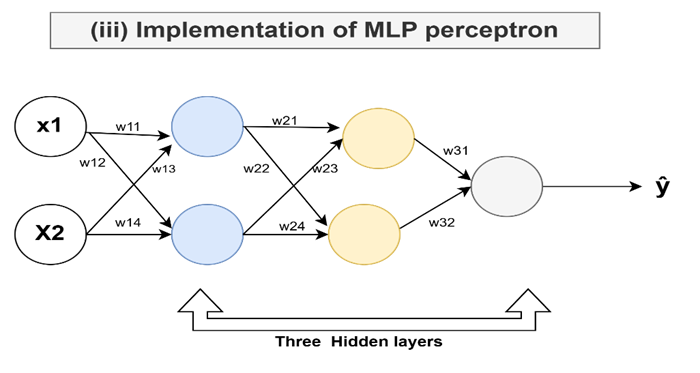

#### Method 1: Manual

In [60]:
# ---------- Activation Functions ----------
def relu(z):
    return max(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [61]:
# ---------- Manual Weighted Sum ----------
def weighted_sum_manual(W, X, b):
    """
    Compute Z = W*X + b manually
    W: weight row vector (1 x n)
    X: input column vector (n x 1)
    b: bias scalar
    """
    Z = 0
    for i in range(len(W)):
        Z += W[i] * X[i,0]
        print(f"W[{i}] * X[{i}] = {W[i]*X[i,0]}")
    Z += b
    print(f"Adding bias {b} → Z = {Z}")
    return Z


In [62]:
# ---------- Manual 3 Hidden Layer MLP ----------
def MLP_3hidden_manual(X):

    # -------- General Check --------
    if not isinstance(X, np.ndarray):
        print("Input must be numpy array")
        return None
    if X.shape != (2,1):
        print("Input shape must be (2,1)")
        return None

    print("\nINPUT VECTOR:\n", X)

    # =====================================
    # Hidden Layer 1 (2 Neurons)
    # =====================================
    print("\n--- Hidden Layer 1 ---")
    W1 = np.array([[0.5, -0.4],   # Neuron 1
                   [0.3, 0.8]])   # Neuron 2
    B1 = np.array([0.2, -0.1])    # biases

    H1 = np.zeros((2,1))
    for i in range(2):
        z = weighted_sum_manual(W1[i], X, B1[i])
        h = relu(z)
        H1[i,0] = h
        print(f"Neuron {i+1}: z = {z}, h = {h}")
    print("H1 Output:\n", H1)

    # =====================================
    # Hidden Layer 2 (2 Neurons)
    # =====================================
    print("\n--- Hidden Layer 2 ---")
    W2 = np.array([[0.7, 0.6],    # Neuron 1
                   [0.2, 0.9]])   # Neuron 2
    B2 = np.array([-0.3, 0.1])

    H2 = np.zeros((2,1))
    for i in range(2):
        z = weighted_sum_manual(W2[i], H1, B2[i])
        h = relu(z)
        H2[i,0] = h
        print(f"Neuron {i+1}: z = {z}, h = {h}")
    print("H2 Output:\n", H2)

    # =====================================
    # Hidden Layer 3 (1 Neuron)
    # =====================================
    print("\n--- Hidden Layer 3 ---")
    W3 = np.array([0.5, 0.8])  # 1 neuron, weights for H2
    B3 = -0.2

    Z3 = weighted_sum_manual(W3, H2, B3)
    H3 = relu(Z3)
    print(f"Hidden Layer 3: z = {Z3}, h = {H3}")

    # =====================================
    # Output Layer (1 Neuron)
    # =====================================
    print("\n--- Output Layer ---")
    W4 = np.array([1.2])  # 1 neuron, weight for H3
    B4 = 0.1

    Z4 = weighted_sum_manual(W4, np.array([[H3]]), B4)
    Y = sigmoid(Z4)
    print(f"Output Layer: z = {Z4}, y = {Y}")

    return Y


In [63]:
X = np.array([[1], [0]])



In [64]:
y =MLP_3hidden_manual(X)


INPUT VECTOR:
 [[1]
 [0]]

--- Hidden Layer 1 ---
W[0] * X[0] = 0.5
W[1] * X[1] = -0.0
Adding bias 0.2 → Z = 0.7
Neuron 1: z = 0.7, h = 0.7
W[0] * X[0] = 0.3
W[1] * X[1] = 0.0
Adding bias -0.1 → Z = 0.19999999999999998
Neuron 2: z = 0.19999999999999998, h = 0.19999999999999998
H1 Output:
 [[0.7]
 [0.2]]

--- Hidden Layer 2 ---
W[0] * X[0] = 0.48999999999999994
W[1] * X[1] = 0.11999999999999998
Adding bias -0.3 → Z = 0.3099999999999999
Neuron 1: z = 0.3099999999999999, h = 0.3099999999999999
W[0] * X[0] = 0.13999999999999999
W[1] * X[1] = 0.18
Adding bias 0.1 → Z = 0.41999999999999993
Neuron 2: z = 0.41999999999999993, h = 0.41999999999999993
H2 Output:
 [[0.31]
 [0.42]]

--- Hidden Layer 3 ---
W[0] * X[0] = 0.15499999999999994
W[1] * X[1] = 0.33599999999999997
Adding bias -0.2 → Z = 0.29099999999999987
Hidden Layer 3: z = 0.29099999999999987, h = 0.29099999999999987

--- Output Layer ---
W[0] * X[0] = 0.34919999999999984
Adding bias 0.1 → Z = 0.4491999999999998
Output Layer: z = 0.449

In [65]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [67]:
print("Finally, Threshold checking y =",predict(y))


Finally, Threshold checking y = 1


#### Method 2: Built in function method

In [68]:
# ---------- Activation Functions ----------
def relu(Z):
    return np.maximum(0, Z)

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

In [70]:
# ---------- Vectorized 3-Hidden-Layer MLP ----------
def MLP_3hidden_vector(X):

    # -------- General Check --------
    if not isinstance(X, np.ndarray):
        print("Input must be a numpy array")
        return None
    if X.shape != (2,1):
        print("Input shape must be (2,1)")
        return None

    print("\nINPUT VECTOR:\n", X)

    # =====================================
    # Hidden Layer 1 (2 Neurons)
    # =====================================
    print("\n--- Hidden Layer 1 ---")
    # input is X vector
    W1 = np.array([[0.5, -0.4],
                   [0.3, 0.8]])       # shape (2,2)
    B1 = np.array([[0.2],
                   [-0.1]])           # shape (2,1)

    Z1 = np.dot(W1, X) + B1
    H1 = relu(Z1)
    print("Z1:\n", Z1)
    print("H1 (after ReLU):\n", H1)

    # =====================================
    # Hidden Layer 2 (2 Neurons)
    # =====================================
    print("\n--- Hidden Layer 2 ---")
    # input from previous layer H1 vector
    W2 = np.array([[0.7, 0.6],
                   [0.2, 0.9]])       # shape (2,2)
    B2 = np.array([[-0.3],
                   [0.1]])            # shape (2,1)

    Z2 = np.dot(W2, H1) + B2
    H2 = relu(Z2)
    print("Z2:\n", Z2)
    print("H2 (after ReLU):\n", H2)

    # =====================================
    # Hidden Layer 3 (1 Neuron)
    # =====================================
    print("\n--- Hidden Layer 3 ---")
    # input from previous layer H2 vector
    W3 = np.array([[0.5, 0.8]])      # shape (1,2)
    B3 = np.array([[-0.2]])          # shape (1,1)

    Z3 = np.dot(W3, H2) + B3
    H3 = relu(Z3)
    print("Z3:\n", Z3)
    print("H3 (after ReLU):\n", H3)

    # =====================================
    # Output Layer (1 Neuron)
    # =====================================
    print("\n--- Output Layer ---")
    W4 = np.array([[1.2]])           # shape (1,1)
    B4 = np.array([[0.1]])           # shape (1,1)

    Z4 = np.dot(W4, H3) + B4
    Y = sigmoid(Z4)
    print("Z4:\n", Z4)
    print("Final Output Y:\n", Y)

    return Y

In [71]:
X = np.array([[1], [0]])


In [72]:
y =MLP_3hidden_manual(X)


INPUT VECTOR:
 [[1]
 [0]]

--- Hidden Layer 1 ---
W[0] * X[0] = 0.5
W[1] * X[1] = -0.0
Adding bias 0.2 → Z = 0.7
Neuron 1: z = 0.7, h = 0.7
W[0] * X[0] = 0.3
W[1] * X[1] = 0.0
Adding bias -0.1 → Z = 0.19999999999999998
Neuron 2: z = 0.19999999999999998, h = 0.19999999999999998
H1 Output:
 [[0.7]
 [0.2]]

--- Hidden Layer 2 ---
W[0] * X[0] = 0.48999999999999994
W[1] * X[1] = 0.11999999999999998
Adding bias -0.3 → Z = 0.3099999999999999
Neuron 1: z = 0.3099999999999999, h = 0.3099999999999999
W[0] * X[0] = 0.13999999999999999
W[1] * X[1] = 0.18
Adding bias 0.1 → Z = 0.41999999999999993
Neuron 2: z = 0.41999999999999993, h = 0.41999999999999993
H2 Output:
 [[0.31]
 [0.42]]

--- Hidden Layer 3 ---
W[0] * X[0] = 0.15499999999999994
W[1] * X[1] = 0.33599999999999997
Adding bias -0.2 → Z = 0.29099999999999987
Hidden Layer 3: z = 0.29099999999999987, h = 0.29099999999999987

--- Output Layer ---
W[0] * X[0] = 0.34919999999999984
Adding bias 0.1 → Z = 0.4491999999999998
Output Layer: z = 0.449

In [73]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [74]:
print("Finally, Threshold checking y =",predict(y))


Finally, Threshold checking y = 1


## 2.4 : Implementation of MLP having 4 hidden layers 1st hidden layer have two perceptrons, 2nd hidden layer have  3 perceptrons , 3rd hidden layer have 2 perceptrons and 4th hidden layer have 1 perceptrons


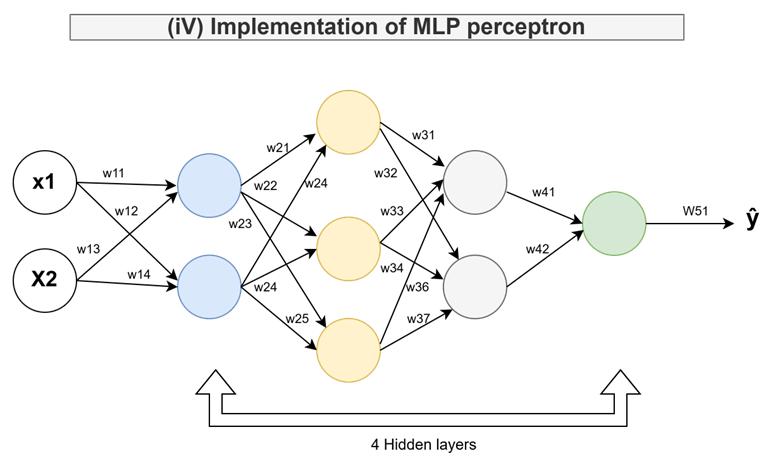

In [75]:
# ---------- Activation Functions ----------
def relu(Z):
    return np.maximum(0, Z)

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))


In [76]:
# ---------- 4 Hidden Layer MLP ----------
def MLP_4Hidden(X):

    # -------- Input Check --------
    if not isinstance(X, np.ndarray):
        print("Input must be numpy array")
        return None

    if X.shape != (2,1):
        print("Input shape must be (2,1)")
        return None

    print("\nINPUT:\n", X)

    # =====================================
    # Hidden Layer 1 (2 neurons)
    # =====================================

    # input vector is X
    W1 = np.array([[0.5, -0.4],
                   [0.3, 0.8]])
    B1 = np.array([[0.2],
                   [-0.1]])

    Z1 = np.dot(W1, X) + B1
    H1 = relu(Z1)
    print("\nH1:\n", H1)

    # =====================================
    # Hidden Layer 2 (3 neurons)
    # =====================================

    # input is H1 vector from previous layer
    W2 = np.array([[0.7, 0.6],
                   [0.2, 0.9],
                   [0.4, -0.5]])
    B2 = np.array([[0.1],
                   [-0.3],
                   [0.2]])

    Z2 = np.dot(W2, H1) + B2
    H2 = relu(Z2)
    print("\nH2:\n", H2)

    # =====================================
    # Hidden Layer 3 (2 neurons)
    # =====================================

    # input from previous layer H2
    W3 = np.array([[0.6, 0.3, 0.5],
                   [0.2, 0.7, -0.4]])
    B3 = np.array([[0.1],
                   [-0.2]])
    Z3 = np.dot(W3, H2) + B3
    H3 = relu(Z3)
    print("\nH3:\n", H3)

    # =====================================
    # Hidden Layer 4 (1 neuron)
    # =====================================

    # input from previous layer H3
    W4 = np.array([[0.8, 0.5]])
    B4 = np.array([[0.2]])
    Z4 = np.dot(W4, H3) + B4
    H4 = relu(Z4)
    print("\nH4:\n", H4)

    # =====================================
    # Output Layer
    # =====================================
    W5 = np.array([[1.2]])
    B5 = np.array([[0.1]])

    Z5 = np.dot(W5, H4) + B5
    Y = sigmoid(Z5)

    print("\nFinal Output:\n", Y)

    return Y

In [77]:
X = np.array([[1], [0]])

In [78]:
y= MLP_4Hidden(X)


INPUT:
 [[1]
 [0]]

H1:
 [[0.7]
 [0.2]]

H2:
 [[0.71]
 [0.02]
 [0.38]]

H3:
 [[0.722]
 [0.   ]]

H4:
 [[0.7776]]

Final Output:
 [[0.73752033]]


In [80]:
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [81]:
print("Finally, Threshold checking y =",predict(y))

Finally, Threshold checking y = 1


## Question # 3: Implememttaion of single perceptron on real dataset and example

### Implementation of Single Perceptron for Mental Stress & Academic Impact Detection Using Student Social Media Dataset


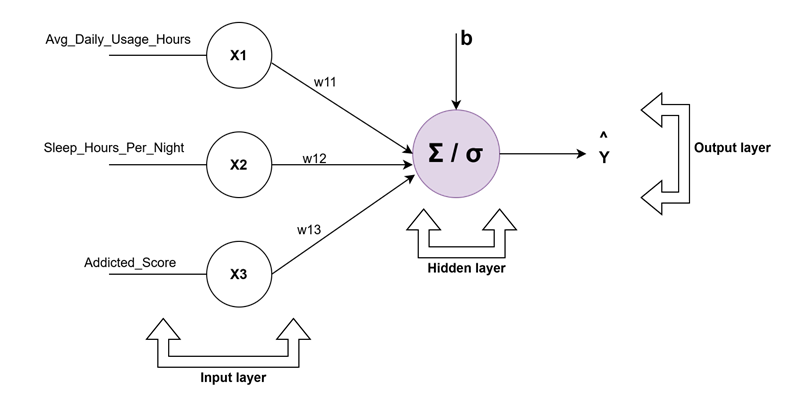

In [82]:
from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hiranawaz2415","key":"7ade3180923fb5ac9db4b376a34cc842"}'}

In [83]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [84]:
!kaggle datasets list

ref                                                                  title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
amar5693/screen-time-sleep-and-stress-analysis-dataset               Screen Time, Sleep & Stress Analysis Dataset            787136  2026-02-13 06:56:18.757000           4464         91  1.0              
amar5693/student-performance-dataset                                 Student Performance Dataset                             177286  2026-02-12 06:04:44.613000           3991         64  1.0              
aliiihussain/amazon-sales-dataset                                    Amazon_Sales_Dataset                                   1297759  2026-02-01 11:37:12.353000           7535      

In [85]:
!kaggle datasets download -d thedrzee/student-social-media-and-relationships --unzip

Dataset URL: https://www.kaggle.com/datasets/thedrzee/student-social-media-and-relationships
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/7.67k [00:00<?, ?B/s]
100% 7.67k/7.67k [00:00<00:00, 23.1MB/s]


#### Step 0: Loading of dataset

In [87]:
import pandas as pd

data = pd.read_csv("Students Social Media Addiction.csv")
print(data.head(5))

   Student_ID  Age  Gender Academic_Level     Country  Avg_Daily_Usage_Hours  \
0           1   19  Female  Undergraduate  Bangladesh                    5.2   
1           2   22    Male       Graduate       India                    2.1   
2           3   20  Female  Undergraduate         USA                    6.0   
3           4   18    Male    High School          UK                    3.0   
4           5   21    Male       Graduate      Canada                    4.5   

  Most_Used_Platform Affects_Academic_Performance  Sleep_Hours_Per_Night  \
0          Instagram                          Yes                    6.5   
1            Twitter                           No                    7.5   
2             TikTok                          Yes                    5.0   
3            YouTube                           No                    7.0   
4           Facebook                          Yes                    6.0   

   Mental_Health_Score Relationship_Status  Conflicts_Over_Soc

In [88]:
# Select input features
X = data[['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Addicted_Score']].values


In [90]:
X

array([[5.2, 6.5, 8. ],
       [2.1, 7.5, 3. ],
       [6. , 5. , 9. ],
       ...,
       [5.6, 6.7, 7. ],
       [4.3, 7.5, 4. ],
       [6.2, 6.3, 8. ]])

#### step 1: Preprocessing of dataset


In [91]:
# Convert target to binary
Y = data['Affects_Academic_Performance'].apply(lambda x: 1 if x == 'Yes' else 0).values


In [92]:
# normalize input features for better perceptron training
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [93]:
print("First 5 input rows:\n", X[:5])
print("First 5 target values:\n", Y[:5])

First 5 input rows:
 [[ 0.22385679 -0.32763788  0.98554997]
 [-2.24330915  0.56042327 -2.16695786]
 [ 0.86054477 -1.65972962  1.61605153]
 [-1.52703517  0.1163927  -1.5364563 ]
 [-0.3332452  -0.77166846  0.3550484 ]]
First 5 target values:
 [1 0 1 0 1]


#### Step 2: Implement Manual Single Perceptron

In [94]:
# weight vector
W = np.array([0.5, -0.3, 0.2])

In [95]:
# bias
b = 0.1

In [96]:
# Perceptron prediction function using sigmoid
def perceptron_predict(x, W, b):
    z = np.dot(W, x) + b
    y_prob = sigmoid(z)  # probability output
    y_binary = predict(y_prob)  # apply threshold
    return y_prob, y_binary

In [97]:
# Sigmoid activation function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [98]:
# converts sigmoid probabilities into hard class labels for binary class classification using threshold
def predict(y):
    if y >= 0.5:
        return 1
    else:
        return 0

In [99]:
# Make predictions for all samples
predictions_prob = []
predictions_binary = []

for x in X:
    prob, binary = perceptron_predict(x, W, b)
    predictions_prob.append(prob)
    predictions_binary.append(binary)

predictions_prob = np.array(predictions_prob)
predictions_binary = np.array(predictions_binary)


In [100]:
print("Sigmoid Probabilities (first 10 samples):", predictions_prob[:10])


Sigmoid Probabilities (first 10 samples): [0.6241803  0.16476772 0.79435867 0.26781698 0.55869997 0.87676293
 0.10704942 0.7066765  0.41374933 0.29186412]


In [101]:
print("Binary Predictions (first 10 samples):", predictions_binary[:10])


Binary Predictions (first 10 samples): [1 0 1 0 1 1 0 1 0 0]


In [102]:
print("Actual values (first 10 samples):", Y[:10])

Actual values (first 10 samples): [1 0 1 0 1 1 0 1 0 0]
